In [21]:
import math
import matplotlib.pyplot as plt
# ---------------------------------------------------------
# 1. Setup & Constants
# ---------------------------------------------------------
G = 4 * (math.pi ** 2)
MS = 1.0                  # Mass of Sun
MJ = 1.0 / 1047.0         # Mass of Jupiter in Solar Masses
AU_TO_KMS = 4.743         # Conversion factor for speed

dt = 0.0002               # Very small time step (flybys are chaotic!)
t_max = 2.5               # 2.5 years
steps = round(t_max / dt)

# INITIAL VOYAGER 2 (Starts at Earth, 1 AU)
vx, vy = 1.0, 0.0
# Escape velocity = sqrt(2 * G * MS / r) = sqrt(8) * Pi
vvx, vvy = 0.0, math.sqrt(8) * math.pi 

# INITIAL JUPITER (Starts at 5.2 AU)
# Phase angle calculated via Barker's equation (~1.65 rad). 
theta_j = 1.6475 
r_j = 5.2
vj_mag = math.sqrt(G * MS / r_j) # Circular velocity

jx = r_j * math.cos(theta_j)
jy = r_j * math.sin(theta_j)
jvx = -vj_mag * math.sin(theta_j)
jvy = vj_mag * math.cos(theta_j)

# Lists for plotting
v_path_x, v_path_y, v_speed = [], [], []
j_path_x, j_path_y = [], []
time_months = []

closest_dist = float('inf')
closest_time = 0.0
current_time_yr = 0.0

# ---------------------------------------------------------
# 2. Integration Loop (Leapfrog)
# ---------------------------------------------------------
print("Simulating Voyager 2 trajectory...")

for _ in range(steps):
    time_months.append(current_time_yr * 12.0)
    
    # Save current stats
    v_path_x.append(vx)
    v_path_y.append(vy)
    j_path_x.append(jx)
    j_path_y.append(jy)
    v_speed.append(math.sqrt(vvx**2 + vvy**2) * AU_TO_KMS)
    
    # Distance tracking for Part 3(b)
    dist_to_jupiter = math.sqrt((vx - jx)**2 + (vy - jy)**2)
    if dist_to_jupiter < closest_dist:
        closest_dist = dist_to_jupiter
        closest_time = current_time_yr * 12.0
        
    # --- CALCULATE ACCELERATIONS ---
    # Jupiter just feels the Sun
    jr = math.sqrt(jx**2 + jy**2)
    jax = -(G * MS / jr**3) * jx
    jay = -(G * MS / jr**3) * jy
    
    # Voyager feels BOTH the Sun and Jupiter!
    vr_sun = math.sqrt(vx**2 + vy**2)
    vr_jup = math.sqrt((vx - jx)**2 + (vy - jy)**2)
    
    vax = -(G * MS / vr_sun**3) * vx - (G * MJ / vr_jup**3) * (vx - jx)
    vay = -(G * MS / vr_sun**3) * vy - (G * MJ / vr_jup**3) * (vy - jy)

    # --- LEAPFROG UPDATE ---
    # 1. KICK (Half-step velocity)
    jvx_half = jvx + jax * (dt / 2.0)
    jvy_half = jvy + jay * (dt / 2.0)
    vvx_half = vvx + vax * (dt / 2.0)
    vvy_half = vvy + vay * (dt / 2.0)
    
    # 2. DRIFT (Full-step position)
    jx = jx + jvx_half * dt
    jy = jy + jvy_half * dt
    vx = vx + vvx_half * dt
    vy = vy + vvy_half * dt
    
    # 3. KICK (Second half-step velocity with NEW accelerations)
    jr_new = math.sqrt(jx**2 + jy**2)
    jax_new = -(G * MS / jr_new**3) * jx
    jay_new = -(G * MS / jr_new**3) * jy
    
    vr_sun_new = math.sqrt(vx**2 + vy**2)
    vr_jup_new = math.sqrt((vx - jx)**2 + (vy - jy)**2)
    vax_new = -(G * MS / vr_sun_new**3) * vx - (G * MJ / vr_jup_new**3) * (vx - jx)
    vay_new = -(G * MS / vr_sun_new**3) * vy - (G * MJ / vr_jup_new**3) * (vy - jy)
    
    jvx = jvx_half + jax_new * (dt / 2.0)
    jvy = jvy_half + jay_new * (dt / 2.0)
    vvx = vvx_half + vax_new * (dt / 2.0)
    vvy = vvy_half + vay_new * (dt / 2.0)
    
    current_time_yr += dt

# Print answers for the report (Part 3b)
print(f"\n--- Flyby Results ---")
print(f"Closest Distance to Jupiter: {closest_dist:.4f} AU")
print(f"Time of Closest Approach:    {closest_time:.2f} Months")

Simulating Voyager 2 trajectory...

--- Flyby Results ---
Closest Distance to Jupiter: 0.0011 AU
Time of Closest Approach:    13.23 Months



Rendering Voyager movie...
Movie saved as 'voyager_assist.mp4'!


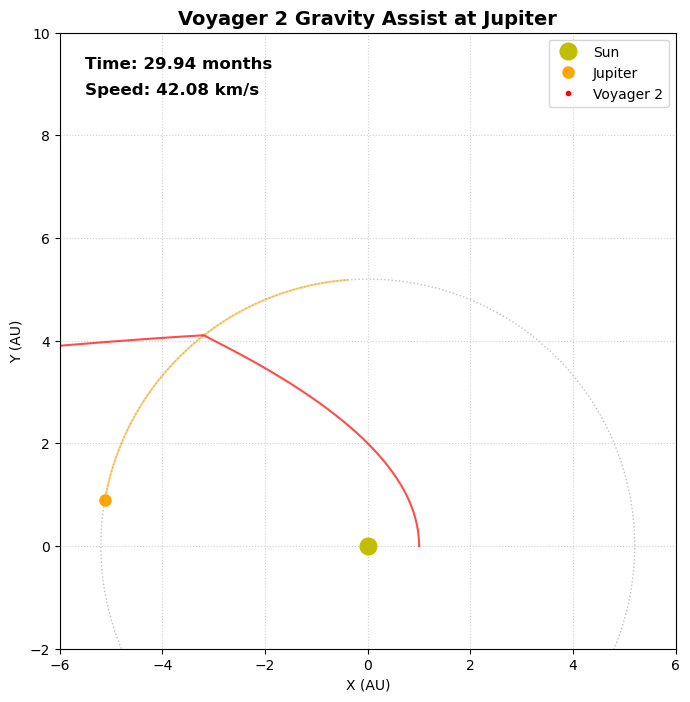

In [22]:
import matplotlib.animation as animation

# ---------------------------------------------------------
# 3. Animation Generation
# ---------------------------------------------------------
print("\nRendering Voyager movie...")

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-6, 6)
ax.set_ylim(-2, 10)
ax.set_aspect('equal')
ax.set_title("Voyager 2 Gravity Assist at Jupiter", fontsize=14, fontweight='bold')
ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")
ax.grid(True, linestyle=':', alpha=0.6)

# Static Sun and Jupiter's orbit ring
ax.plot(0, 0, 'yo', markersize=12, label="Sun")
circle = plt.Circle((0, 0), 5.2, color='gray', fill=False, linestyle=':', alpha=0.5)
ax.add_patch(circle)

# Moving elements
jup_trail, = ax.plot([], [], 'orange', alpha=0.5)
jup_dot, = ax.plot([], [], 'o', color='orange', markersize=8, label="Jupiter")

voy_trail, = ax.plot([], [], 'r-', alpha=0.7)
voy_dot, = ax.plot([], [], 'r.', markersize=6, label="Voyager 2")

# Text labels for the top of the screen
time_text = ax.text(-5.5, 9.3, "", fontsize=12, fontweight='bold')
speed_text = ax.text(-5.5, 8.8, "", fontsize=12, fontweight='bold')

ax.legend(loc='upper right')

def update(i):
    # Update trails and dots
    jup_trail.set_data(j_path_x[:i], j_path_y[:i])
    jup_dot.set_data([j_path_x[i]], [j_path_y[i]])
    
    voy_trail.set_data(v_path_x[:i], v_path_y[:i])
    voy_dot.set_data([v_path_x[i]], [v_path_y[i]])
    
    # Update text counter
    time_text.set_text(f"Time: {time_months[i]:.2f} months")
    speed_text.set_text(f"Speed: {v_speed[i]:.2f} km/s")
    
    return jup_trail, jup_dot, voy_trail, voy_dot, time_text, speed_text

# Skip 25 frames at a time so the animation runs at a good speed
ani = animation.FuncAnimation(fig, update, frames=range(0, steps, 25), interval=20, blit=True)

writer = animation.FFMpegWriter(fps=30)
ani.save('voyager_assist.mp4', writer=writer)

print("Movie saved as 'voyager_assist.mp4'!")

During flyby, the voyager's heliocentric speed will increase significantly.
Closest Distance to Jupiter~ 0.001 AU
Time of Closest Approach~    13.2 Months